# MLP & Quantization

G = $X W_g$ 2048 x 4096, 4096 x 14336

U = $X W_u$ 2048 x 4096, 4096 x 14336

Z = $SiLU(G) \otimes U$ , 2048 x 14336, 2048 x 14336

Y = $Z W_d$ 2048 x 14336, 14336 x 4096

Residual

RMSNorm

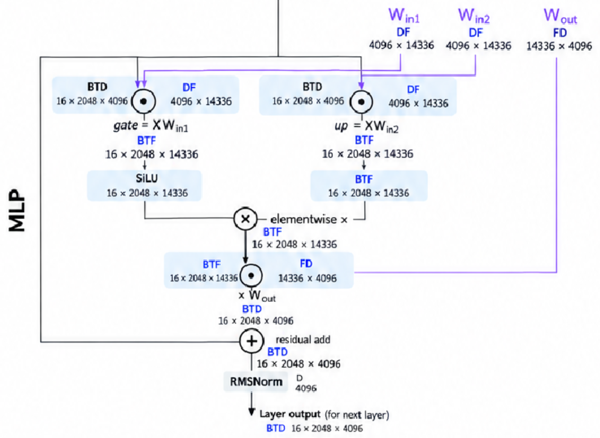

In [3]:
from helper import plot
plot("img/MLP.png", 600)

## Smooth Quant

    # OFFLINE: run once when preparing the model.
    # W shape: [Din, Dout]

    Collect representative input activations X_calibration

    FOR each input channel k
        activation_max[k] = max(abs(X_calibration[:, k]))
        weight_max[k]     = max(abs(W[k, :]))

        s[k] = activation_max[k]^alpha / weight_max[k]^(1-alpha)
        # Use s[k] = 1 for a zero activation or weight channel.
    END FOR

    # alpha is calibrated; 0.5 is a starting value.
    W_smooth = s[:, None] * W

    FOR each output channel n
        weight_scale[n] = max(abs(W_smooth[:, n])) / 127
        # Use scale = 1 for an all-zero column.

        W8[:, n] = clip(
            round(W_smooth[:, n] / weight_scale[n]),
            -127, 127
        )
    END FOR

    Store W8 in DRAM, packed as output-channel rows
    Store s and weight_scale in DRAM

    # ONE linear layer
    # Input:  X16 [tokens, Din] in DRAM
    # Weight: W8  [Din, Dout] in DRAM
    # Output: Y16 [tokens, Dout] in DRAM

    DMA load smoothing scales s into SRAM
    WAIT

    FOR each query/token row tile

        DMA load X16 tile into SRAM
        WAIT

        VCPU decode X16 into its represented values
        VCPU smooth input:
            X_smooth[:, k] = X[:, k] / s[k]

        VCPU find one quantization scale per token:
            input_scale[row] = max(abs(X_smooth[row, :])) / 127
            # Use scale = 1 for an all-zero row.

        VCPU quantize:
            X8 = clip(
                round(X_smooth / input_scale[:, None]),
                -127, 127
            )

        SRAM write X8 and input_scale
        WAIT

        FOR each output-channel tile

            DMA load corresponding weight_scale into SRAM
            VCPU initialize C32 = 0
            WAIT

            FOR each reduction chunk across Din

                DMA load corresponding W8 chunk into SRAM
                WAIT

                SA1 compute assigned output rows
                SA2 compute assigned output rows

                VCPU accumulate the chunk result into C32

                # DMA may prefetch the next W8 chunk into
                # a separate buffer while current computation runs.

            END FOR

            VCPU recover the represented output:
                Y = input_scale[:, None] * C32 * weight_scale[None, :]

            VCPU encode Y into the required A16 format
            SRAM write Y16
            DMA store Y16 to DRAM
            WAIT

        END FOR
    END FOR

## Prefill

    # ONE MLP layer
    # X16: [B*T, D]
    # Wgate8, Wup8: [D, F]
    # Wdown8: [F, D]

    FOR each token tile in B*T

        DMA load X16 tile
        WAIT

        RUN CONCURRENTLY:
            VCPU pack X16; initialize Y32 = 0
            DMA load first gate/up/down weight tile
        WAIT for both

        FOR each hidden-feature tile across F

            WAIT for current weights
            VCPU pack W8
            VCPU initialize Gate32, Up32 = 0

            FOR each reduction chunk across D
                SA1/SA2 compute gate/up partial products
                SRAM write raw INT16 partials

                VCPU reconstruct and accumulate Gate32, Up32
                # Overlap with the next array batch.
                # DMA prefetch next weights into another buffer.

            WAIT for complete Gate32 and Up32

            VCPU compute Z = SiLU(Gate32) * Up32
            VCPU encode Z16 and pack its digits

            FOR each output tile across D
                SA1/SA2 compute Z16 × Wdown8 partial products
                SRAM write raw INT16 partials

                VCPU reconstruct and accumulate Y32
                # Overlap with the next array batch.

            WAIT before reusing buffers

        VCPU encode Y32 → Y16
        DMA store Y16